In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor


In [2]:
df = pd.read_csv(
    "Airport_Arrival_ATFM_Delay.csv",
    low_memory=False
)

In [3]:
display(df.head())

,YEAR,MONTH_NUM,MONTH_MON,FLT_DATE,APT_ICAO,APT_NAME,STATE_NAME,FLT_ARR_1,DLY_APT_ARR_1,DLY_APT_ARR_A_1,...,DLY_APT_ARR_V_1,DLY_APT_ARR_W_1,DLY_APT_ARR_NA_1,FLT_ARR_1_DLY,FLT_ARR_1_DLY_15,ATFM_VERSION,Pivot Label,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,2019,1,JAN,1-Jan-2019,EBAW,Antwerp,Belgium,5,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,v2,Antwerp (EBAW),NaN,NaN,NaN
1,2019,1,JAN,1-Jan-2019,EBBR,Brussels,Belgium,205,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,v2,Brussels (EBBR),NaN,NaN,NaN
2,2019,1,JAN,1-Jan-2019,EBCI,Charleroi,Belgium,55,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,v2,Charleroi (EBCI),NaN,NaN,NaN
3,2019,1,JAN,1-Jan-2019,EBLG,Liège,Belgium,13,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,v2,Liège (EBLG),NaN,NaN,NaN
4,2019,1,JAN,1-Jan-2019,EBOS,Ostend-Bruges,Belgium,6,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,v2,Ostend-Bruges (EBOS),NaN,NaN,NaN


In [4]:
print(df.shape)

(997537, 32)


In [5]:
df = df.dropna(axis=1, how='all')

In [6]:
df = df.drop(columns=['ATFM_VERSION', 'Pivot Label', 'MONTH_MON'])


In [7]:
df = df.fillna(df.median(numeric_only=True))
df = df.fillna(df.mode().iloc[0])

In [8]:
print(df.shape)

(997537, 27)


In [9]:
display(df.head())

,YEAR,MONTH_NUM,FLT_DATE,APT_ICAO,APT_NAME,STATE_NAME,FLT_ARR_1,DLY_APT_ARR_1,DLY_APT_ARR_A_1,DLY_APT_ARR_C_1,...,DLY_APT_ARR_P_1,DLY_APT_ARR_R_1,DLY_APT_ARR_S_1,DLY_APT_ARR_T_1,DLY_APT_ARR_V_1,DLY_APT_ARR_W_1,DLY_APT_ARR_NA_1,FLT_ARR_1_DLY,FLT_ARR_1_DLY_15,Unnamed: 31
0,2019,1,1-Jan-2019,EBAW,Antwerp,Belgium,5,0,0,0,...,0,0.0,0,0,0,0,0.0,12.0,4.0,
1,2019,1,1-Jan-2019,EBBR,Brussels,Belgium,205,0,0,0,...,0,0.0,0,0,0,0,0.0,12.0,4.0,
2,2019,1,1-Jan-2019,EBCI,Charleroi,Belgium,55,0,0,0,...,0,0.0,0,0,0,0,0.0,12.0,4.0,
3,2019,1,1-Jan-2019,EBLG,Liège,Belgium,13,0,0,0,...,0,0.0,0,0,0,0,0.0,12.0,4.0,
4,2019,1,1-Jan-2019,EBOS,Ostend-Bruges,Belgium,6,0,0,0,...,0,0.0,0,0,0,0,0.0,12.0,4.0,


In [10]:
df['FLT_DATE'] = pd.to_datetime(df['FLT_DATE'])


In [11]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

In [12]:
df['season'] = df['MONTH_NUM'].apply(get_season)

In [13]:
df['weekday'] = df['FLT_DATE'].dt.dayofweek

In [14]:
print(df[['FLT_DATE', 'MONTH_NUM', 'season', 'weekday']].head())

    FLT_DATE  MONTH_NUM  season  weekday
0 2019-01-01          1  Winter        1
1 2019-01-01          1  Winter        1
2 2019-01-01          1  Winter        1
3 2019-01-01          1  Winter        1
4 2019-01-01          1  Winter        1


In [15]:
print(df.isnull().sum())


YEAR                0
MONTH_NUM           0
FLT_DATE            0
APT_ICAO            0
APT_NAME            0
STATE_NAME          0
FLT_ARR_1           0
DLY_APT_ARR_1       0
DLY_APT_ARR_A_1     0
DLY_APT_ARR_C_1     0
DLY_APT_ARR_D_1     0
DLY_APT_ARR_E_1     0
DLY_APT_ARR_G_1     0
DLY_APT_ARR_I_1     0
DLY_APT_ARR_M_1     0
DLY_APT_ARR_N_1     0
DLY_APT_ARR_O_1     0
DLY_APT_ARR_P_1     0
DLY_APT_ARR_R_1     0
DLY_APT_ARR_S_1     0
DLY_APT_ARR_T_1     0
DLY_APT_ARR_V_1     0
DLY_APT_ARR_W_1     0
DLY_APT_ARR_NA_1    0
FLT_ARR_1_DLY       0
FLT_ARR_1_DLY_15    0
Unnamed: 31         0
season              0
weekday             0
dtype: int64


In [16]:
df = df.drop(columns=['Unnamed: 31'])


In [17]:
dly_cols = [col for col in df.columns if 'DLY' in col]


In [18]:
df[dly_cols] = df[dly_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

In [19]:
print(df.dtypes)

YEAR                         int64
MONTH_NUM                    int64
FLT_DATE            datetime64[ns]
APT_ICAO                    object
APT_NAME                    object
STATE_NAME                  object
FLT_ARR_1                    int64
DLY_APT_ARR_1              float64
DLY_APT_ARR_A_1            float64
DLY_APT_ARR_C_1            float64
DLY_APT_ARR_D_1            float64
DLY_APT_ARR_E_1            float64
DLY_APT_ARR_G_1            float64
DLY_APT_ARR_I_1            float64
DLY_APT_ARR_M_1            float64
DLY_APT_ARR_N_1            float64
DLY_APT_ARR_O_1            float64
DLY_APT_ARR_P_1            float64
DLY_APT_ARR_R_1            float64
DLY_APT_ARR_S_1            float64
DLY_APT_ARR_T_1            float64
DLY_APT_ARR_V_1            float64
DLY_APT_ARR_W_1            float64
DLY_APT_ARR_NA_1           float64
FLT_ARR_1_DLY              float64
FLT_ARR_1_DLY_15           float64
season                      object
weekday                      int32
dtype: object


In [20]:
print((df[dly_cols] < 0).sum())


DLY_APT_ARR_1       0
DLY_APT_ARR_A_1     0
DLY_APT_ARR_C_1     0
DLY_APT_ARR_D_1     0
DLY_APT_ARR_E_1     0
DLY_APT_ARR_G_1     0
DLY_APT_ARR_I_1     0
DLY_APT_ARR_M_1     0
DLY_APT_ARR_N_1     0
DLY_APT_ARR_O_1     0
DLY_APT_ARR_P_1     0
DLY_APT_ARR_R_1     0
DLY_APT_ARR_S_1     0
DLY_APT_ARR_T_1     0
DLY_APT_ARR_V_1     0
DLY_APT_ARR_W_1     0
DLY_APT_ARR_NA_1    0
FLT_ARR_1_DLY       0
FLT_ARR_1_DLY_15    0
dtype: int64


In [21]:
print(df['YEAR'].unique())

[2019 2020 2021 2022 2023 2024 2025 2026]


In [22]:
print(df['STATE_NAME'].unique())

['Belgium' 'Germany' 'Estonia' 'Finland' 'United Kingdom' 'Netherlands'
 'Ireland' 'Denmark' 'Luxembourg' 'Norway' 'Poland' 'Sweden' 'Latvia'
 'Lithuania' 'Spain' 'Morocco' 'Albania' 'Bulgaria' 'Cyprus' 'Croatia'
 'France' 'Greece' 'Hungary' 'Italy' 'Slovenia' 'Czech Republic' 'Israel'
 'Malta' 'Austria' 'Portugal' 'Bosnia and Herzegovina' 'Romania'
 'Switzerland' 'Türkiye' 'Moldova' 'Republic of North Macedonia' 'Serbia'
 'Montenegro' 'Slovakia' 'Armenia' 'Georgia' 'Ukraine' 'Iceland']


In [23]:
print(df['FLT_ARR_1'].describe())

count    997537.000000
mean         55.252673
std         100.556389
min           0.000000
25%           5.000000
50%          17.000000
75%          57.000000
max         844.000000
Name: FLT_ARR_1, dtype: float64


In [24]:
print(df['APT_ICAO'].nunique())

405


In [25]:
df.to_csv('clean_data.csv', index=False)


In [26]:
df['avg_delay'] = df['DLY_APT_ARR_1'] / df['FLT_ARR_1'].replace(0, 1)


In [27]:
df['delayed_flag'] = (df['avg_delay'] > 15).astype(int)


In [28]:
print(df['delayed_flag'].value_counts())


delayed_flag
0    995416
1      2121
Name: count, dtype: int64


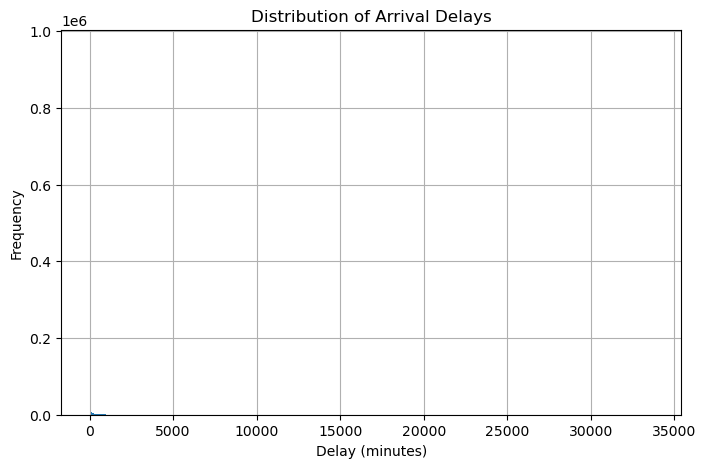

In [29]:
plt.figure(figsize=(8,5))
df['DLY_APT_ARR_1'].hist(bins=500)
plt.title('Distribution of Arrival Delays')
plt.xlabel('Delay (minutes)')
plt.ylabel('Frequency')
plt.show()

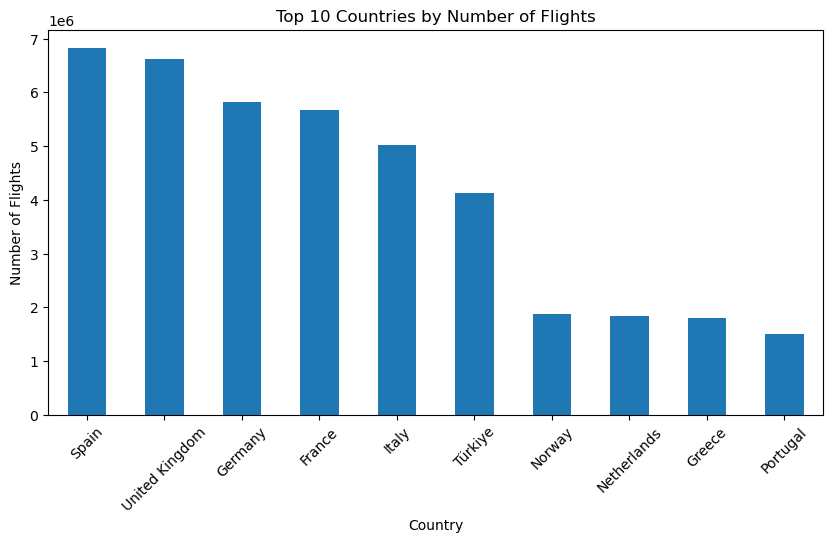

In [30]:
import matplotlib.pyplot as plt

top10 = df.groupby('STATE_NAME')['FLT_ARR_1'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top10.plot(kind='bar')
plt.title('Top 10 Countries by Number of Flights')
plt.xlabel('Country')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45)
plt.show()

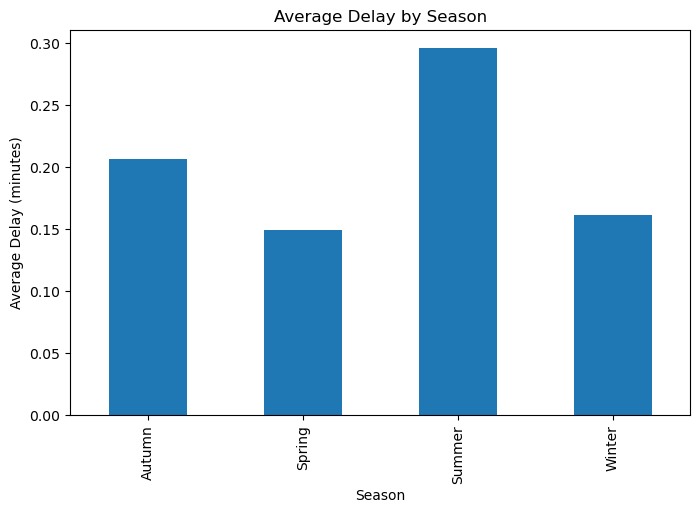

In [31]:
plt.figure(figsize=(8,5))
df.groupby('season')['avg_delay'].mean().plot(kind='bar')
plt.title('Average Delay by Season')
plt.xlabel('Season')
plt.ylabel('Average Delay (minutes)')
plt.show()

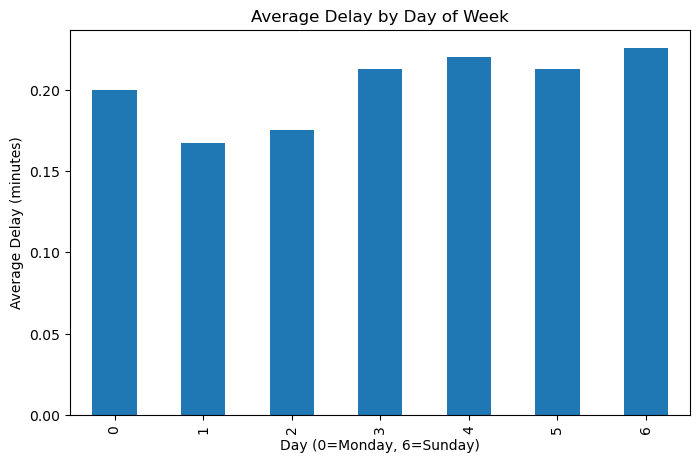

In [32]:
plt.figure(figsize=(8,5))
df.groupby('weekday')['avg_delay'].mean().plot(kind='bar')
plt.title('Average Delay by Day of Week')
plt.xlabel('Day (0=Monday, 6=Sunday)')
plt.ylabel('Average Delay (minutes)')
plt.show()

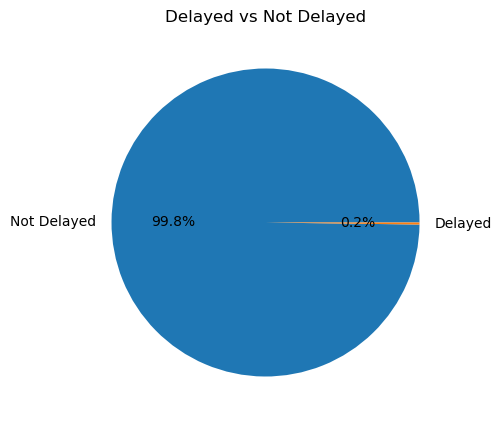

In [33]:
plt.figure(figsize=(5,5))

df['delayed_flag'].value_counts().rename(index={0:'Not Delayed', 1:'Delayed'}).plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Delayed vs Not Delayed')
plt.ylabel('')
plt.show()

In [34]:
print(df.describe())


                YEAR      MONTH_NUM                       FLT_DATE  \
count  997537.000000  997537.000000                         997537   
mean     2022.205804       6.361134  2022-09-10 06:02:17.173858560   
min      2019.000000       1.000000            2019-01-01 00:00:00   
25%      2020.000000       3.000000            2020-11-15 00:00:00   
50%      2022.000000       6.000000            2022-09-15 00:00:00   
75%      2024.000000       9.000000            2024-07-12 00:00:00   
max      2026.000000      12.000000            2026-04-30 00:00:00   
std         2.126673       3.472004                            NaN   

           FLT_ARR_1  DLY_APT_ARR_1  DLY_APT_ARR_A_1  DLY_APT_ARR_C_1  \
count  997537.000000  997537.000000    997537.000000    997537.000000   
mean       55.252673      33.792856         0.070657         5.748520   
min         0.000000       0.000000         0.000000         0.000000   
25%         5.000000       0.000000         0.000000         0.000000   
50% 

In [35]:
print(df['STATE_NAME'].value_counts())

STATE_NAME
France                         184188
Spain                          125912
Italy                          115478
United Kingdom                  79386
Germany                         59191
Greece                          40714
Türkiye                         39493
Poland                          36953
Portugal                        29270
Romania                         28879
Norway                          26741
Sweden                          21357
Ireland                         19479
Switzerland                     18081
Netherlands                     15958
Austria                         15924
Morocco                         15749
Belgium                         13248
Croatia                         10511
Lithuania                       10454
Czech Republic                  10251
Denmark                          8029
Bulgaria                         7657
Slovenia                         7356
Cyprus                           5285
Estonia                          4811
U

In [36]:
df['FLT_DATE'] = pd.to_datetime(df['FLT_DATE'])
df['YEAR'] = df['YEAR'].astype('int32')
df['MONTH_NUM'] = df['MONTH_NUM'].astype('int32')
df['weekday'] = df['weekday'].astype('int32')
df['FLT_ARR_1'] = df['FLT_ARR_1'].astype('int32')

In [37]:
print(df.dtypes) 

YEAR                         int32
MONTH_NUM                    int32
FLT_DATE            datetime64[ns]
APT_ICAO                    object
APT_NAME                    object
STATE_NAME                  object
FLT_ARR_1                    int32
DLY_APT_ARR_1              float64
DLY_APT_ARR_A_1            float64
DLY_APT_ARR_C_1            float64
DLY_APT_ARR_D_1            float64
DLY_APT_ARR_E_1            float64
DLY_APT_ARR_G_1            float64
DLY_APT_ARR_I_1            float64
DLY_APT_ARR_M_1            float64
DLY_APT_ARR_N_1            float64
DLY_APT_ARR_O_1            float64
DLY_APT_ARR_P_1            float64
DLY_APT_ARR_R_1            float64
DLY_APT_ARR_S_1            float64
DLY_APT_ARR_T_1            float64
DLY_APT_ARR_V_1            float64
DLY_APT_ARR_W_1            float64
DLY_APT_ARR_NA_1           float64
FLT_ARR_1_DLY              float64
FLT_ARR_1_DLY_15           float64
season                      object
weekday                      int32
avg_delay           

In [38]:
df.head()

,YEAR,MONTH_NUM,FLT_DATE,APT_ICAO,APT_NAME,STATE_NAME,FLT_ARR_1,DLY_APT_ARR_1,DLY_APT_ARR_A_1,DLY_APT_ARR_C_1,...,DLY_APT_ARR_T_1,DLY_APT_ARR_V_1,DLY_APT_ARR_W_1,DLY_APT_ARR_NA_1,FLT_ARR_1_DLY,FLT_ARR_1_DLY_15,season,weekday,avg_delay,delayed_flag
0,2019,1,2019-01-01,EBAW,Antwerp,Belgium,5,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,12.0,4.0,Winter,1,0.0,0
1,2019,1,2019-01-01,EBBR,Brussels,Belgium,205,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,12.0,4.0,Winter,1,0.0,0
2,2019,1,2019-01-01,EBCI,Charleroi,Belgium,55,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,12.0,4.0,Winter,1,0.0,0
3,2019,1,2019-01-01,EBLG,Liège,Belgium,13,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,12.0,4.0,Winter,1,0.0,0
4,2019,1,2019-01-01,EBOS,Ostend-Bruges,Belgium,6,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,12.0,4.0,Winter,1,0.0,0


In [39]:
df['avg_delay'] = df['DLY_APT_ARR_1'] / df['FLT_ARR_1'].replace(0, 1)

print("Target variable summary:")
print(df['avg_delay'].describe())

Target variable summary:
count    997537.000000
mean          0.201910
std           2.436144
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        1032.000000
Name: avg_delay, dtype: float64


In [53]:
df['airport_avg_delay'] = df.groupby('APT_ICAO')['DLY_APT_ARR_1'].transform('mean')

df['country_avg_delay'] = df.groupby('STATE_NAME')['DLY_APT_ARR_1'].transform('mean')

df['airport_flight_load'] = df.groupby('APT_ICAO')['FLT_ARR_1'].transform('sum')

df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)

In [54]:
features = [
    'MONTH_NUM',
    'weekday',
    'season',
    'STATE_NAME',
    'FLT_ARR_1',
    'airport_avg_delay',
    'country_avg_delay',
    'airport_flight_load',
    'is_weekend'
]

In [55]:
X = df[features].copy()
y = df['avg_delay'].copy()

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1220122
)

print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")

Training samples : 798,029
Test samples     : 199,508


## 6. Preprocessing Pipeline

We build a `ColumnTransformer` that:
- **Numeric columns**: fills missing values with the column mean, then applies `StandardScaler`.
- **Categorical columns**: fills missing values with the most frequent value, then applies `OneHotEncoder`.

This pipeline is shared between both models to ensure a fair comparison.


In [60]:
cat_selector = make_column_selector(dtype_include='object')
num_selector = make_column_selector(dtype_include='number')

# Categorical pipeline
cat_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(sparse_output=False, handle_unknown='ignore')
)

# Numeric pipeline
num_pipe = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler()
)

preprocessor = ColumnTransformer([
    ('categorical', cat_pipe, cat_selector),
    ('numeric',     num_pipe, num_selector)
], verbose_feature_names_out=False)

print("✅ Preprocessing pipeline built.")


✅ Preprocessing pipeline built.


## 7. Model 1: Linear Regression

**Linear Regression** is our baseline model.  
It assumes that the average delay is a linear combination of the input features.

**Why Linear Regression?**
- Simple and interpretable
- Fast to train even on large datasets
- Provides a baseline to compare against more complex models


In [61]:
lr_pipe = make_pipeline(preprocessor, LinearRegression())
lr_pipe.fit(X_train, y_train)

y_train_pred_lr = lr_pipe.predict(X_train)
y_test_pred_lr  = lr_pipe.predict(X_test)

lr_results = {
    'Train MAE':  mean_absolute_error(y_train, y_train_pred_lr),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred_lr)),
    'Train R²':   r2_score(y_train, y_train_pred_lr),
    'Test MAE':   mean_absolute_error(y_test,  y_test_pred_lr),
    'Test RMSE':  np.sqrt(mean_squared_error(y_test,  y_test_pred_lr)),
    'Test R²':    r2_score(y_test,  y_test_pred_lr),
}

print("── Linear Regression Results ──")
for k, v in lr_results.items():
    print(f"  {k}: {v:.4f}")


── Linear Regression Results ──
  Train MAE: 0.3561
  Train RMSE: 2.5466
  Train R²: 0.0205
  Test MAE: 0.3489
  Test RMSE: 1.7483
  Test R²: 0.0419


## 8. Model 2: Decision Tree Regressor

**Decision Tree Regressor** is our second model.  
It learns decision rules from the data by recursively splitting features.

**Why Decision Tree?**
- Captures non-linear relationships that Linear Regression cannot
- Easy to interpret visually
- No assumption about data distribution

We limit `max_depth=6` to prevent overfitting.


In [62]:
# We rebuild the preprocessor fresh for the second pipeline
preprocessor2 = ColumnTransformer([
    ('categorical', make_pipeline(
        SimpleImputer(strategy='most_frequent'),
        OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    ), cat_selector),
    ('numeric', make_pipeline(
        SimpleImputer(strategy='mean'),
        StandardScaler()
    ), num_selector)
], verbose_feature_names_out=False)

dt_pipe = make_pipeline(
    preprocessor2,
    DecisionTreeRegressor(max_depth=6, random_state=42)
)
dt_pipe.fit(X_train, y_train)

y_train_pred_dt = dt_pipe.predict(X_train)
y_test_pred_dt  = dt_pipe.predict(X_test)

dt_results = {
    'Train MAE':  mean_absolute_error(y_train, y_train_pred_dt),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred_dt)),
    'Train R²':   r2_score(y_train, y_train_pred_dt),
    'Test MAE':   mean_absolute_error(y_test,  y_test_pred_dt),
    'Test RMSE':  np.sqrt(mean_squared_error(y_test,  y_test_pred_dt)),
    'Test R²':    r2_score(y_test,  y_test_pred_dt),
}

print("── Decision Tree Results ──")
for k, v in dt_results.items():
    print(f"  {k}: {v:.4f}")


── Decision Tree Results ──
  Train MAE: 0.3008
  Train RMSE: 2.3688
  Train R²: 0.1525
  Test MAE: 0.2937
  Test RMSE: 1.7174
  Test R²: 0.0755


## 9. Model Comparison

We compare both models side-by-side using a summary table and a bar chart.  
The best model is selected based on **Test R²** (how much variance in delay is explained)  
and **Test MAE** (average prediction error in minutes).


In [63]:
summary = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Linear Regression (Train)': [lr_results['Train MAE'], lr_results['Train RMSE'], lr_results['Train R²']],
    'Linear Regression (Test)':  [lr_results['Test MAE'],  lr_results['Test RMSE'],  lr_results['Test R²']],
    'Decision Tree (Train)':     [dt_results['Train MAE'], dt_results['Train RMSE'], dt_results['Train R²']],
    'Decision Tree (Test)':      [dt_results['Test MAE'],  dt_results['Test RMSE'],  dt_results['Test R²']],
})
summary = summary.set_index('Metric').round(4)
print(summary.to_string())


        Linear Regression (Train)  Linear Regression (Test)  Decision Tree (Train)  Decision Tree (Test)
Metric                                                                                                  
MAE                        0.3561                    0.3489                 0.3008                0.2937
RMSE                       2.5466                    1.7483                 2.3688                1.7174
R²                         0.0205                    0.0419                 0.1525                0.0755


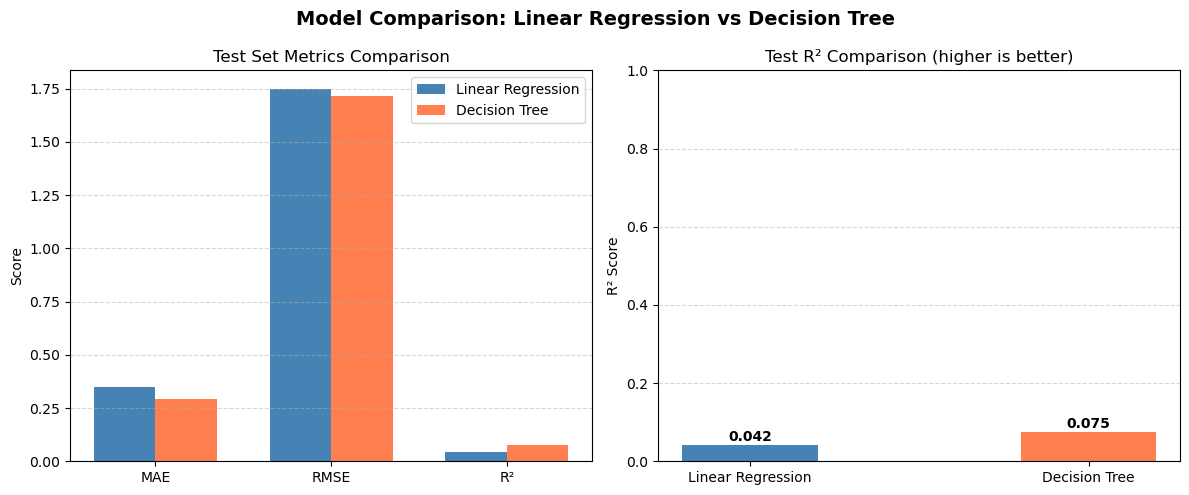

Figure saved.


In [68]:
os.makedirs('figures', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Model Comparison: Linear Regression vs Decision Tree', fontsize=14, fontweight='bold')

metrics = ['MAE', 'RMSE', 'R²']
lr_test_vals = [lr_results['Test MAE'], lr_results['Test RMSE'], lr_results['Test R²']]
dt_test_vals = [dt_results['Test MAE'], dt_results['Test RMSE'], dt_results['Test R²']]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, lr_test_vals, width, label='Linear Regression', color='steelblue')
axes[0].bar(x + width/2, dt_test_vals, width, label='Decision Tree',     color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_title('Test Set Metrics Comparison')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# R² only
r2_vals = [lr_results['Test R²'], dt_results['Test R²']]
bars = axes[1].bar(['Linear Regression', 'Decision Tree'], r2_vals,
                    color=['steelblue', 'coral'], width=0.4)
axes[1].set_title('Test R² Comparison (higher is better)')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1)
for bar, val in zip(bars, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


## 10. Best Model Diagnostics

We now analyse the best-performing model in more detail using:
1. **Actual vs Predicted plot** – how closely do predictions follow reality?  
2. **Residuals plot** – are errors randomly distributed (good) or systematic (bad)?


Best model: Decision Tree


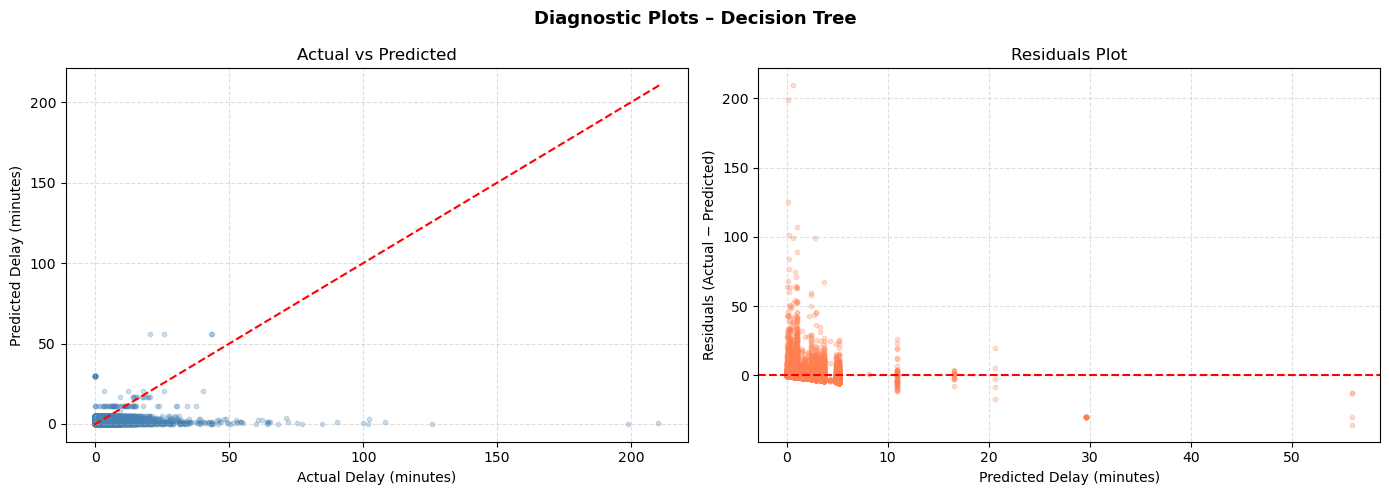

In [69]:
import os
os.makedirs('figures', exist_ok=True)

# Pick the best model based on test R²
if dt_results['Test R²'] >= lr_results['Test R²']:
    best_name   = 'Decision Tree'
    y_test_pred = y_test_pred_dt
else:
    best_name   = 'Linear Regression'
    y_test_pred = y_test_pred_lr

print(f"Best model: {best_name}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Diagnostic Plots – {best_name}', fontsize=13, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_test, y_test_pred, alpha=0.25, s=10, color='steelblue')
lim = [min(y_test.min(), y_test_pred.min()) - 0.5,
       max(y_test.max(), y_test_pred.max()) + 0.5]
axes[0].plot(lim, lim, 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Delay (minutes)')
axes[0].set_ylabel('Predicted Delay (minutes)')
axes[0].set_title('Actual vs Predicted')
axes[0].grid(linestyle='--', alpha=0.4)

# Residuals
residuals = y_test.values - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.25, s=10, color='coral')
axes[1].axhline(0, color='r', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Delay (minutes)')
axes[1].set_ylabel('Residuals (Actual − Predicted)')
axes[1].set_title('Residuals Plot')
axes[1].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('figures/diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Feature Importance (Decision Tree)

Decision Trees provide a built-in feature importance score.  
Higher values mean that feature contributes more to reducing prediction error.


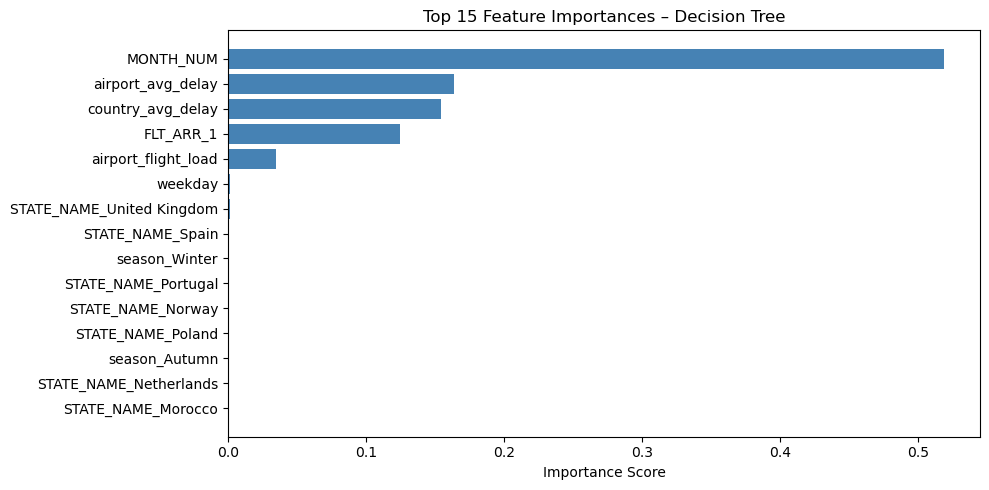

                  Feature  Importance
                MONTH_NUM    0.518791
        airport_avg_delay    0.163928
        country_avg_delay    0.154227
                FLT_ARR_1    0.124442
      airport_flight_load    0.035056
                  weekday    0.001826
STATE_NAME_United Kingdom    0.001259
         STATE_NAME_Spain    0.000359
            season_Winter    0.000107
      STATE_NAME_Portugal    0.000006
        STATE_NAME_Norway    0.000000
        STATE_NAME_Poland    0.000000
            season_Autumn    0.000000
   STATE_NAME_Netherlands    0.000000
       STATE_NAME_Morocco    0.000000


In [70]:
dt_model = dt_pipe.named_steps['decisiontreeregressor']
preprocessor_dt = dt_pipe.named_steps['columntransformer']

feature_names = preprocessor_dt.get_feature_names_out()
importances   = dt_model.feature_importances_

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 5))
plt.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importances – Decision Tree')
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(feat_df.to_string(index=False))


## 12. Cross-Validation

We use 5-fold cross-validation to validate that our results are stable and not due to a lucky split.  
This is especially important for models like Decision Tree which can overfit.


In [71]:
from sklearn.model_selection import cross_val_score

cv_lr = cross_val_score(lr_pipe, X, y, cv=5, scoring='r2')
cv_dt = cross_val_score(dt_pipe, X, y, cv=5, scoring='r2')

print("Linear Regression – 5-Fold CV R²:")
print(f"  Scores : {cv_lr.round(4)}")
print(f"  Mean   : {cv_lr.mean():.4f}  |  Std: {cv_lr.std():.4f}")

print()

print("Decision Tree – 5-Fold CV R²:")
print(f"  Scores : {cv_dt.round(4)}")
print(f"  Mean   : {cv_dt.mean():.4f}  |  Std: {cv_dt.std():.4f}")


Linear Regression – 5-Fold CV R²:
  Scores : [ 0.0154 -0.0449  0.02    0.0471  0.0145]
  Mean   : 0.0104  |  Std: 0.0301

Decision Tree – 5-Fold CV R²:
  Scores : [-0.803  -3.5183 -0.9098  0.0735  0.022 ]
  Mean   : -1.0271  |  Std: 1.3101


## 13. Example Predictions

To demonstrate the model in action, we create three realistic airport scenarios  
and ask the best model to predict the expected average arrival delay.


In [ ]:


scenarios = pd.DataFrame([
    {
        'MONTH_NUM': 12,
        'weekday': 4,
        'YEAR': 2023,
        'FLT_ARR_1': 300,
        'season': 'Winter',
        'STATE_NAME': 'Germany'
    },
    {
        'MONTH_NUM': 7,
        'weekday': 2,
        'YEAR': 2023,
        'FLT_ARR_1': 10,
        'season': 'Summer',
        'STATE_NAME': 'Estonia'
    },
    {
        'MONTH_NUM': 8,
        'weekday': 0,
        'YEAR': 2023,
        'FLT_ARR_1': 500,
        'season': 'Summer',
        'STATE_NAME': 'Spain'
    }
])

predictions = best_pipe.predict(scenarios)

print("Predictions:\n")

labels = [
    "Busy German airport, winter Friday",
    "Small Estonian airport, summer Wednesday",
    "Very busy Spanish airport, peak summer Monday"
]

for label, pred in zip(labels, predictions):
    print(f"{label}")
    print(f"→ Predicted avg delay: {pred:.2f} minutes\n")

Predictions:

Busy German airport, winter Friday
→ Predicted avg delay: 0.65 minutes

Small Estonian airport, summer Wednesday
→ Predicted avg delay: 0.03 minutes

Very busy Spanish airport, peak summer Monday
→ Predicted avg delay: 0.65 minutes

